# Quantum Counting for Subset Sum

This notebook demonstrates the quantum counting algorithm using Grover’s operator
to estimate the number of subset-sum solutions for small problem instances.

We compare:
- Exact classical counts
- Quantum estimated counts (simulator)

This experiment evaluates accuracy across different targets and precision levels.

In [20]:
from Final_Project.oracle import subset_sum_oracle
from Final_Project.counting import quantum_counting_circuit, estimate_solutions

In [21]:
import qiskit
import matplotlib
import matplotlib.pyplot as plt
print(qiskit.__version__)
print(matplotlib.__version__)

2.3.0
3.10.8


In [22]:
from qiskit.visualization import plot_histogram
from qiskit_aer import AerSimulator
from qiskit import transpile

def run_precision_test(weights, target, max_t=8, true_solutions=None):
    """
    The Experiment Runner: 
    Iterates through different 'precision' levels (t) to show how 
    Quantum Counting converges on the correct answer.
    """
    n = len(weights)

    # Handle the empty set case classically
    if n == 0:
        print("Empty Set Detected (n=0):")
        res = 1 if target == 0 else 0
        print(f"Result: {res} solution(s). (No quantum circuit required)")
        return res
    
    # GROUND TRUTH: Calculate the real answer using classical brute force if no true_solution provided.
    # We do this so we can plot a 'Target Line' on our graph to check accuracy.
    if true_solutions is None:
        from itertools import combinations
        true_solutions = sum(1 for r in range(n + 1) 
                             for c in combinations(weights, r) if sum(c) == target)
    
    # We test t from 3 up to max_t (e.g., 8) to see the accuracy improve.
    t_values = list(range(3, max_t + 1))
    estimates = []
    final_counts = None # To store the last histogram
    
    print(f"Testing Subset Sum {weights} for Target {target}")
    print(f"Targeting M = {true_solutions} solutions in a search space of N = {2**n}")
    print("-" * 65)

    # EXPERIMENT LOOP
    for t in t_values:
        # Build the complete counting circuit for the current precision 't'
        oracle = subset_sum_oracle(weights, target)
        qc = quantum_counting_circuit(n, oracle, counting_qubits=t)
        
        # Run Simulation
        backend = AerSimulator()
        compiled = transpile(qc, backend)
        result = backend.run(compiled, shots=2048).result()
        counts = result.get_counts()
        
        # ESTIMATE THE PHASE
        # We find the bitstring (peak) that was measured most often.
        measured = max(counts, key=counts.get)
        measured_value = int(measured, 2)

        # CONVERT PHASE TO M
        # Use our sin^2 formula to turn the measured bitstring into a solution count.
        est = estimate_solutions(measured_value, n, t)
        estimates.append(est)
        
        print(f"t={t} | Most Probable: {measured:>{max_t}} | Est. M: {est}")
        
        # Save the highest precision counts for the histogram
        if t == max_t:
            final_counts = counts

    # --- Plot 1: Convergence Graph ---
    plt.figure(figsize=(10, 4))
    plt.plot(t_values, estimates, 'bo-', linewidth=2, label='Quantum Estimate')
    plt.axhline(y=true_solutions, color='r', linestyle='--', label=f'True M ({true_solutions})')
    plt.xlabel('Counting Qubits (t)')
    plt.ylabel('Estimated Solutions (M)')
    plt.title(f'Convergence Analysis (Weights {weights})')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.show()

    # --- Plot 2: Histogram of Highest Precision ---

    # Convert bitstrings to integers for a cleaner plot
    int_counts = {int(k, 2): v for k, v in final_counts.items()}

    # Use the top 20 most frequent to keep the plot readable
    top_int_counts = dict(sorted(int_counts.items(), key=lambda item: item[1], reverse=True)[:20])

    print(f"\nTop Phase Register Peaks for t={max_t}:")
    display(plot_histogram(top_int_counts, figsize=(12, 5), 
                        title=f"Measurement Distribution (Top Peaks) for t={max_t}"))


Testing Subset Sum [1, 2, 3] for Target 3
Targeting M = 2 solutions in a search space of N = 8
-----------------------------------------------------------------
t=3 | Most Probable:      011 | Est. M: 1
t=4 | Most Probable:     0101 | Est. M: 2
t=5 | Most Probable:    01011 | Est. M: 2
t=6 | Most Probable:   010101 | Est. M: 2
t=7 | Most Probable:  0101011 | Est. M: 2
t=8 | Most Probable: 01010101 | Est. M: 2


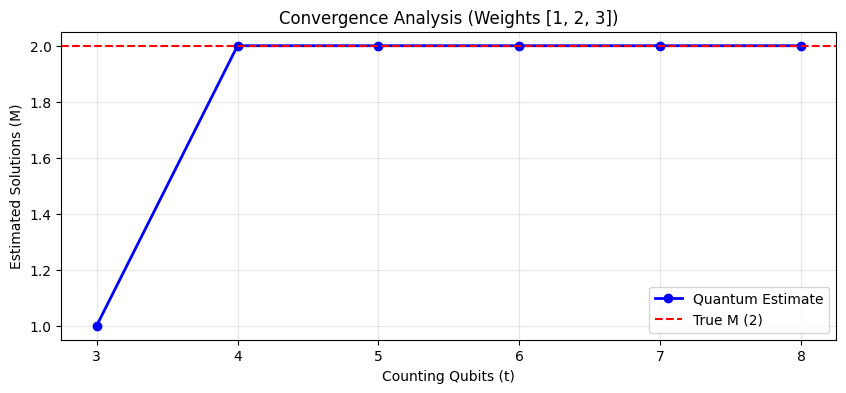


Top Phase Register Peaks for t=8:


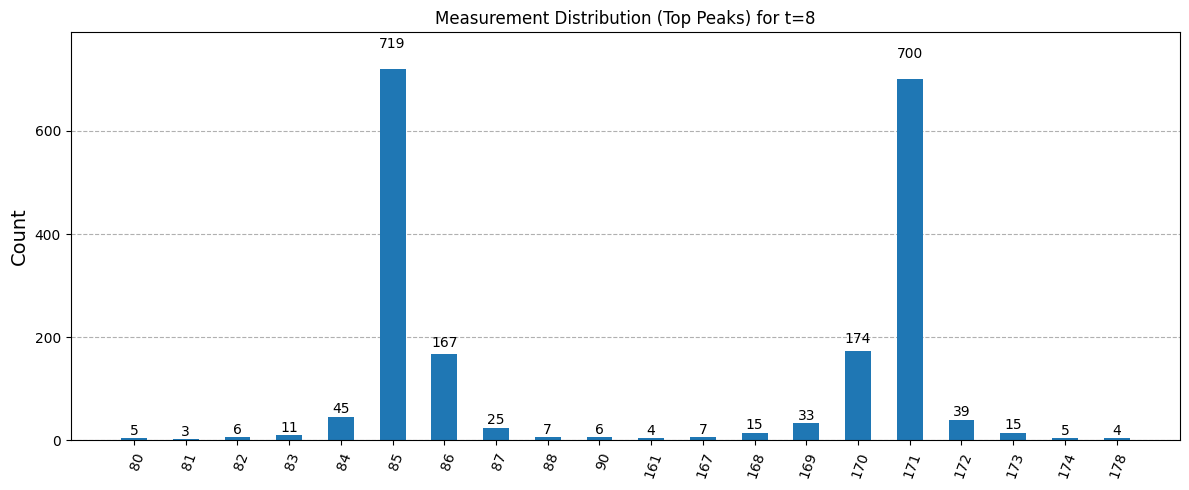

In [23]:
# Run it!
run_precision_test([1, 2, 3], 3, max_t=8)

Testing Subset Sum [1, 1, 1, 1] for Target 2
Targeting M = 6 solutions in a search space of N = 16
-----------------------------------------------------------------


t=3 | Most Probable:      110 | Est. M: 8
t=4 | Most Probable:     1011 | Est. M: 5
t=5 | Most Probable:    10111 | Est. M: 6
t=6 | Most Probable:   101101 | Est. M: 6
t=7 | Most Probable:  1011011 | Est. M: 6
t=8 | Most Probable: 10110110 | Est. M: 6


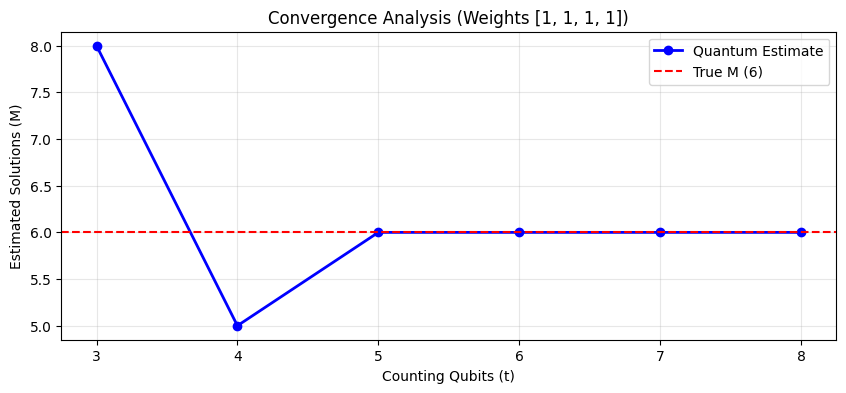


Top Phase Register Peaks for t=8:


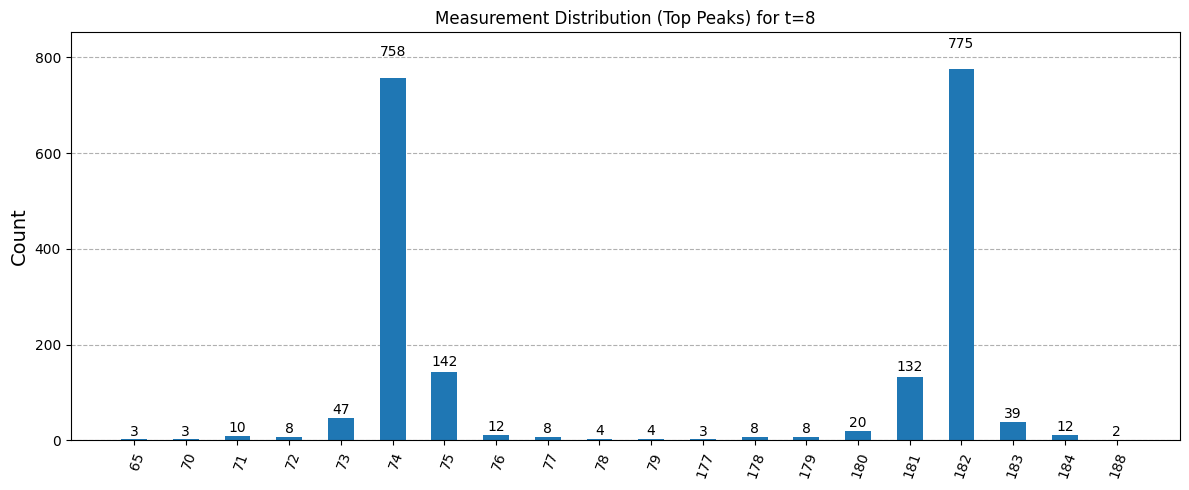

In [24]:
run_precision_test([1, 1, 1, 1], 2, max_t=8)#, true_solutions=6)

Testing Subset Sum [1, 2, 4, 5, 6] for Target 7
Targeting M = 3 solutions in a search space of N = 32
-----------------------------------------------------------------
t=3 | Most Probable:      011 | Est. M: 5
t=4 | Most Probable:     1010 | Est. M: 5
t=5 | Most Probable:    10011 | Est. M: 3
t=6 | Most Probable:   100110 | Est. M: 3
t=7 | Most Probable:  1001101 | Est. M: 3
t=8 | Most Probable: 10011001 | Est. M: 3


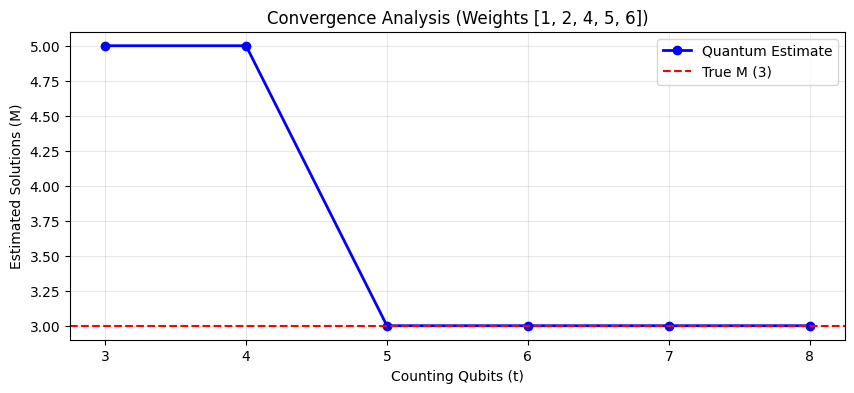


Top Phase Register Peaks for t=8:


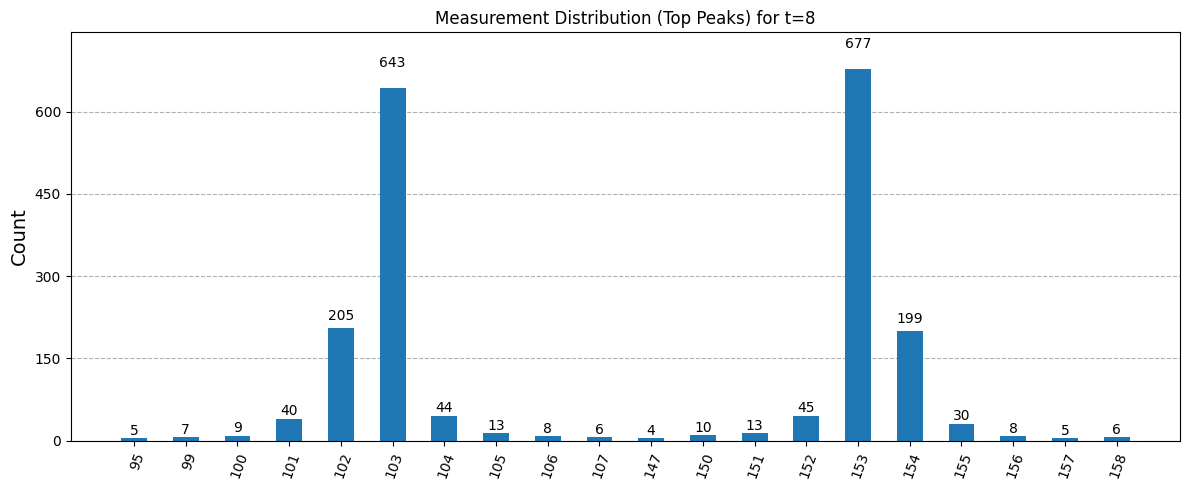

In [25]:
run_precision_test([1, 2, 4, 5, 6], 7, max_t=8, true_solutions=3)

Testing Subset Sum [5] for Target 20
Targeting M = 0 solutions in a search space of N = 2
-----------------------------------------------------------------


t=3 | Most Probable:      100 | Est. M: 0
t=4 | Most Probable:     1000 | Est. M: 0
t=5 | Most Probable:    10000 | Est. M: 0
t=6 | Most Probable:   100000 | Est. M: 0
t=7 | Most Probable:  1000000 | Est. M: 0
t=8 | Most Probable: 10000000 | Est. M: 0


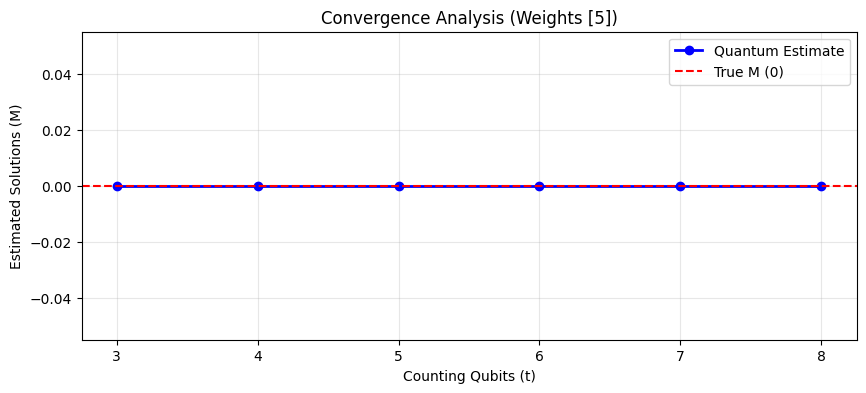


Top Phase Register Peaks for t=8:


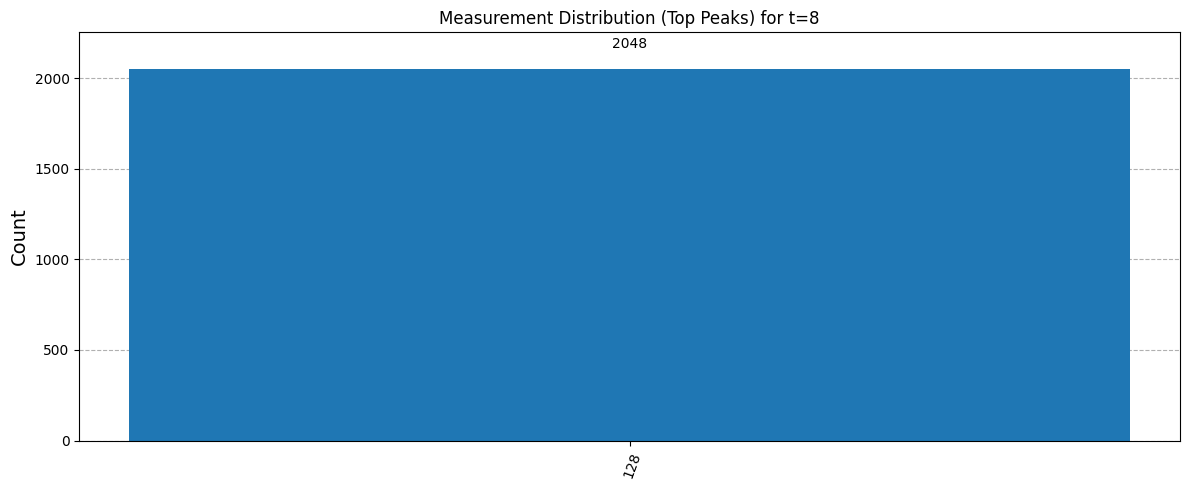

In [26]:
run_precision_test([5], 20, max_t=8, true_solutions=0)